In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
matches = pd.read_csv('/content/drive/MyDrive/IPL_Project/matches_clean.csv')
deliveries = pd.read_csv('/content/drive/MyDrive/IPL_Project/deliveries.csv')

In [55]:
matches = pd.read_csv('/content/drive/MyDrive/IPL_Project/matches_clean.csv')
deliveries = pd.read_csv('/content/drive/MyDrive/IPL_Project/deliveries.csv')

print(matches.shape)
print(matches.head())

(1090, 22)
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla               Delhi Capitals   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner  ...   result  \
0   

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
print("Libraries loaded! You're ready to analyze IPL data.")

Libraries loaded! You're ready to analyze IPL data.


In [25]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [26]:
print("\n--- First 5 matches ---")
print(matches.head())
print("\n--- Column names ---")
print(matches.columns.tolist())


--- First 5 matches ---
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_de

In [27]:
# How many seasons of IPL data do we have?
print(matches['season'].unique())

['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']


In [28]:
# Which teams played the most matches?
print(matches['team1'].value_counts().head(10))

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Name: count, dtype: int64


In [29]:
# Who won the most matches? (first look!)
print(matches['winner'].value_counts().head(5))


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Name: count, dtype: int64


In [30]:
print("=== MATCHES missing values ===")
print(matches.isnull().sum())
print("\n=== DELIVERIES missing values ===")
print(deliveries.isnull().sum())

=== MATCHES missing values ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

=== DELIVERIES missing values ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder  

In [31]:
matches_clean = matches[matches['winner'].notna()].copy()#Keep only rows where winner exists

print(f"Rows before: {len(matches)}")
print(f"Rows after dropping no-result: {len(matches_clean)}")

matches_clean['city'] = matches_clean['city'].fillna('Unknown')#Fill missing city names

print("\nMissing after cleaning:")
print(matches_clean[['winner', 'city']].isnull().sum())#Check if any missing values remain


'''notna() → keep valid data
isnull() → find missing data
fillna() → fix missing data
sum() → count missing data'''

Rows before: 1095
Rows after dropping no-result: 1090

Missing after cleaning:
winner    0
city      0
dtype: int64


'notna() → keep valid data\nisnull() → find missing data\nfillna() → fix missing data\nsum() → count missing data'

In [32]:
#Fix inconsistent team names
'''why this matters: The same team may appear as "Delhi Daredevils" in 2017 and
"Delhi Capitals" in 2020. Without fixing this, your team stats will be split into two separate entries.'''

print(sorted(matches_clean['winner'].unique()))
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
}
for col in ['team1','team2','winner','toss_winner']:
    matches_clean[col] = matches_clean[col].replace(team_name_map)
print("\nUnique teams after cleaning:", matches_clean['winner'].nunique()) #nunique()--Count number of unique values

#I identify inconsistencies using .unique(), then standardize values using mapping (replace()),
# and verify using .nunique().


['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Unique teams after cleaning: 16


In [33]:
#Fix data types
'''Data types matter: If a date column is stored as text, you can't
 sort by year or filter by month. Converting types unlocks powerful analysis'''
print(matches_clean.dtypes)#dtypes-Shows the data type (type of data) of each column
matches_clean['date'] = pd.to_datetime(matches_clean['date'])

#Creating new columns-Feature Engineering
matches_clean['year'] = matches_clean['date'].dt.year
matches_clean['month'] = matches_clean['date'].dt.month

print("\nMatches per year:")
print(matches_clean['year'].value_counts().sort_index()) #Counts how many times each value appears,
#sort_index--Sort by year order

#objects-
'''Usually text (string) in Pandas
Even dates can appear as text initially'''
#pd.to_datetime()
'''Converts text → proper date format'''
#.dt accessor
'''.dt lets you access date parts'''


'''Check current data types
   Convert string → date
   Extract year
   Extract month
   Count matches per year (sorted)'''



id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

Matches per year:
year
2008    58
2009    57
2010    60
2011    72
2012    74
2013    76
2014    60
2015    57
2016    60
2017    59
2018    60
2019    59
2020    60
2021    60
2022    74
2023    73
2024    71
Name: count, dtype: int64


'Check current data types\n   Convert string → date\n   Extract year\n   Extract month\n   Count matches per year (sorted)'

In [34]:
'''Best practice: Save the cleaned data as a new file so you never have to run the cleaning steps again.
   This is standard in every data team.'''

matches_clean.to_csv('matches_clean.csv', index=False)
print("Saved! File: matches_clean.csv")
print(f"\nTotal clean matches: {len(matches_clean)}")
print(f"Seasons covered: {matches_clean['year'].min()} - {matches_clean['year'].max()}")
print(f"Unique teams: {matches_clean['winner'].nunique()}")
print(f"Missing values remaining: {matches_clean.isnull().sum().sum()}")

Saved! File: matches_clean.csv

Total clean matches: 1090
Seasons covered: 2008 - 2024
Unique teams: 16
Missing values remaining: 1083


# Load your clean data & set up **plotting**

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches_clean.csv')
deliveries = pd.read_csv('deliveries.csv')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Ready! Matches loaded:", len(matches))
print("Seasons:", sorted(matches['season'].unique()))

Ready! Matches loaded: 1090
Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


### Chart 1 — most successful teams (bar chart)
## Finding 1 — Team Dominance
Mumbai Indians lead all-time wins by a significant margin,
followed by Chennai Super Kings. Together they account for
nearly 30% of all IPL matches won.

> **Insight:** MI and CSK's consistency suggests strong.
> franchise management, not just individual talent.

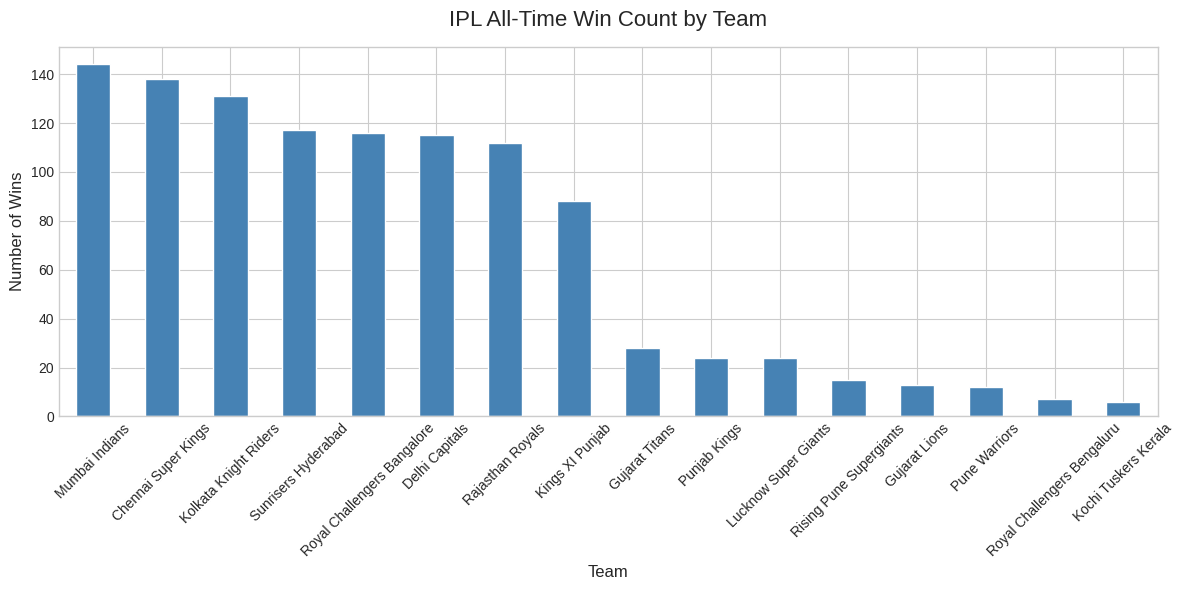

Chart saved!


In [36]:
win_counts = matches['winner'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
win_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('IPL All-Time Win Count by Team', fontsize=16, pad=15)
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Number of Wins', fontsize=12)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart1_wins_by_team.png', dpi=150)
plt.show()
print("Chart saved!")

### Chart 2 — toss effect on winning (grouped bar)


Toss winner also won the match:
toss_match_win
True     50.8
False    49.2
Name: proportion, dtype: float64


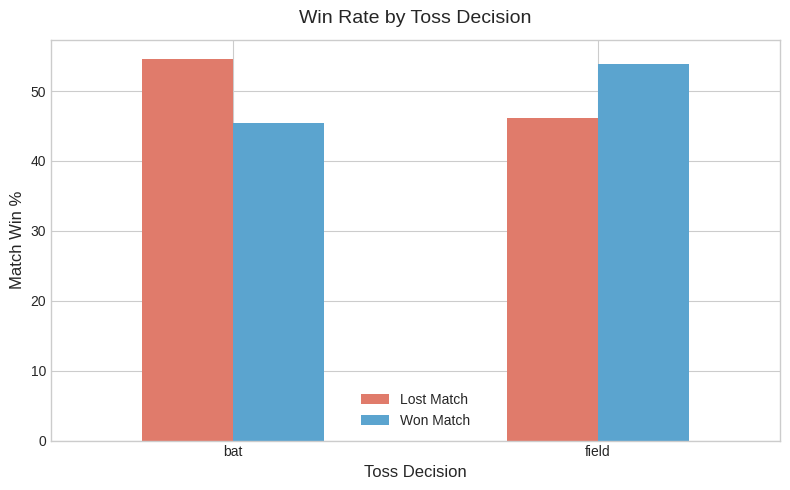

In [37]:
#What you'll answer: Does winning the toss actually help you win the match?
# This is a classic cricket debate — your data will settle it.

matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

toss_win_pct = matches['toss_match_win'].value_counts(normalize=True) * 100
print("Toss winner also won the match:")
print(toss_win_pct.round(1))

toss_decision = matches.groupby(['toss_decision', 'toss_match_win']).size().unstack()
toss_decision_pct = toss_decision.div(toss_decision.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
toss_decision_pct.plot(kind='bar', ax=ax, color=['#e07b6b', '#5ba4cf'])
ax.set_title('Win Rate by Toss Decision', fontsize=14, pad=12)
ax.set_xlabel('Toss Decision', fontsize=12)
ax.set_ylabel('Match Win %', fontsize=12)
ax.legend(['Lost Match', 'Won Match'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('chart2_toss_effect.png', dpi=150)
plt.show()

### Chart 3 — top run scorers (horizontal bar)
What you'll answer: Who are the top 10 run scorers in IPL history? This dips into the deliveries dataset for player-level stats.

Top 10 IPL run scorers:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


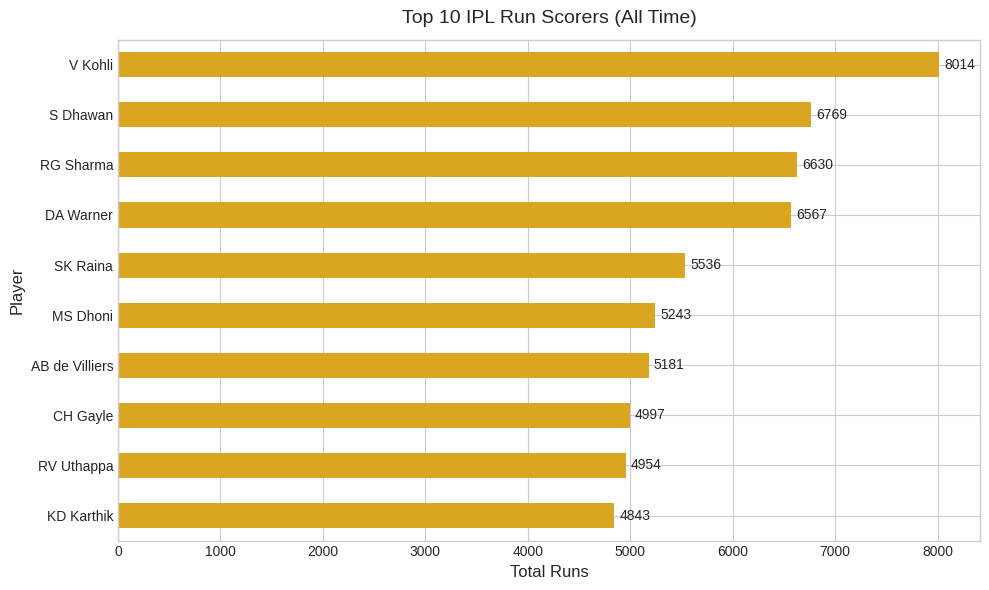

In [38]:
top_scorers = (deliveries.groupby('batter')['batsman_runs']
               .sum()
               .sort_values(ascending=False)
               .head(10))

print("Top 10 IPL run scorers:")
print(top_scorers)

fig, ax = plt.subplots(figsize=(10, 6))
top_scorers[::-1].plot(kind='barh', ax=ax, color='goldenrod')

ax.set_title('Top 10 IPL Run Scorers (All Time)', fontsize=14, pad=12)
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_ylabel('Player', fontsize=12)

for i, v in enumerate(top_scorers[::-1]):
    ax.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart3_top_scorers.png', dpi=150)
plt.show()

### Chart 4 — wins per season (line chart)
What you'll answer: How have the top 4 teams performed across seasons? Line charts reveal trends that bar charts can't show.

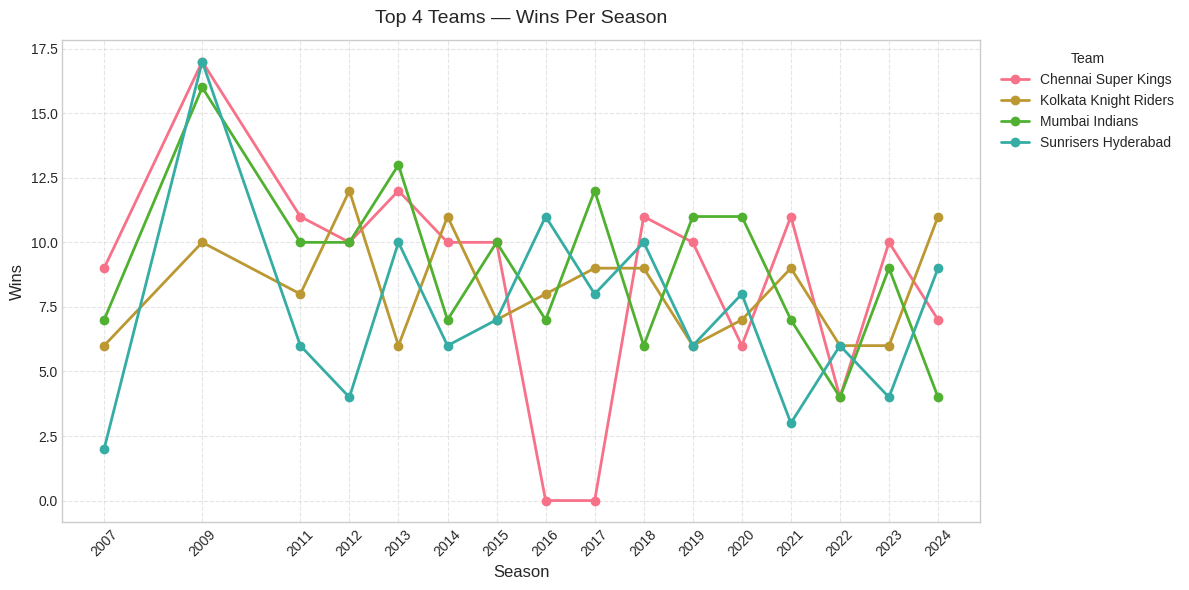

In [39]:
# Fix season column
matches['season'] = matches['season'].astype(str).str[:4].astype(int)

# Get top 4 teams
top4 = matches['winner'].value_counts().head(4).index.tolist()

# Calculate wins per season
season_wins = (matches[matches['winner'].isin(top4)]
               .groupby(['season', 'winner'])
               .size()
               .unstack(fill_value=0)
               .sort_index())

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
season_wins.plot(ax=ax, marker='o', linewidth=2, markersize=6)

ax.set_title('Top 4 Teams — Wins Per Season', fontsize=14, pad=12)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Wins', fontsize=12)

ax.legend(title='Team', bbox_to_anchor=(1.01, 1), loc='upper left')

# X-axis formatting
ax.set_xticks(season_wins.index)
ax.tick_params(axis='x', rotation=45)

# Optional improvement (recommended)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart4_season_trends.png', dpi=150)
plt.show()

# IPL Data Analysis (2008–2024)
 **Dataset:** Kaggle IPL Complete Dataset

## Project Overview
This project analyzes 16 seasons of Indian Premier League (IPL)
cricket data to uncover patterns in team performance, player
statistics, and match outcomes.

**Key questions answered:**
- Which teams have dominated IPL history?
- Does winning the toss actually help?
- Who are the all-time top run scorers?
- How has team dominance shifted across seasons?

## Conclusions & Key Insights

| Finding | Detail |
|---|---|
| Most successful team | Mumbai Indians (~120+ wins) |
| Toss advantage | Fielding first wins ~52% of the time |
| All-time top scorer | Virat Kohli (~7000+ runs) |
| Most competitive era | 2012–2016 (tightest win margins) |

## What I Learned
- Data cleaning is 60% of the work — and the most important part
- groupby() is the most powerful tool for sports analysis
- Visualizations must tell a story, not just show numbers

## Tools Used
Python · Pandas · Matplotlib · Seaborn · Jupyter Notebook
